#  Native-space Identification of Insula with T1w images (3T/7T)

In [ ]:
# TUS preprocessing for feature based attention project
# Steps:
# 0. get standardized masks of target regions
# 1. inverse registration of MNI space to native space 
# 2. get cordinates and save for Brainsite Neuronavigation format
# Inputs:
# -T1 in 3T (not necessarilly in RAS orientation)
# -Any brain regions (e.g., aMCC) probability map (converted to RAS)
# Last update/notes:
# - Neuronavigation converts coordinates automatically
# ====================================================================================================================
%reset -f

# Load modules/packages
from mri_python import * 
globals().update(configure_mri_env())

# Basic
import cv2 
import scipy.io
from scipy.spatial.distance import cdist
from scipy.ndimage import center_of_mass, gaussian_filter
from scipy.ndimage import binary_fill_holes, binary_closing, label

# Nipype
import nibabel as nib
from nipype.interfaces.spm import NewSegment
from nipype.interfaces.matlab import MatlabCommand
from nibabel.orientations import io_orientation, axcodes2ornt, ornt_transform, apply_orientation
os.environ["NILEARN_DATA"] = "/Users/atsushikikumoto/Dropbox/w_ONGOINGANY/atlases"

# Nilearn
from nilearn import datasets, image, masking, plotting
from nilearn.image import math_img, resample_to_img, new_img_like

# Ants
# https://github.com/ANTsX/ANTs?tab=readme-ov-file
# https://github.com/antsx/antspy
import ants

# Skin
import trimesh
from trimesh.proximity import ProximityQuery
from skimage.transform import resize

# MNI space/LC probability map templates
from templateflow.api import get
t1_mni_path = get('MNI152NLin2009cAsym', resolution=1, suffix='T1w', extension='nii.gz')
t1_mni = ants.image_read(str([p for p in t1_mni_path if 'desc-brain' not in str(p)][0]))
t1_mni_brain = ants.image_read(str([p for p in t1_mni_path if 'desc-brain' in str(p)][0]))

# Define paths 
DIR_HERE = Path(os.path.dirname(os.path.realpath("__file__")))
DIR_DATA = Path.home() / "Dropbox (Personal)" / "w_SCRIPTS" / "P.TUSPractice" / "TUS_LSRDM" / "PilotData" / "LCScan_Pilot"/ "7T"
# DIR_DATA = Path.home() / "Dropbox (Personal)" / "w_SCRIPTS" / "P.TUSPractice" / "SUB_LIST_PREP" 
DIR_MASK_TMP = DIR_HERE / 'z_masks_templates'
DIR_MASK_OUT = DIR_HERE / 'z_masks_outputs'
# DIR_DATA_i = [d for d in DIR_DATA.iterdir() if d.is_dir()]

# Files
DIR_T1FILES = list(DIR_DATA.rglob('sub-*_T1w_7T.nii'))
DIR_T1C1FILES = list(DIR_DATA.rglob('c1*.nii'))
DIR_T1C2FILES = list(DIR_DATA.rglob('c2*.nii'))
DIR_T1C3FILES = list(DIR_DATA.rglob('c3*.nii'))
DIR_T1C4FILES = list(DIR_DATA.rglob('c4*.nii'))
DIR_T1C5FILES = list(DIR_DATA.rglob('c5*.nii'))
DIR_T1C6FILES = list(DIR_DATA.rglob('c6*.nii'))
DIR_SKINFILES = list(DIR_DATA.rglob('sub-*Skin.stl'))
SUBJECT_ID = [f.stem.split("_")[0] for f in DIR_T1FILES]

%whos

Variable                       Type         Data/Info
-----------------------------------------------------
Counter                        type         <class 'collections.Counter'>
DIR_DATA                       PosixPath    /Users/atsushikikumoto/Dr<...>PilotData/LCScan_Pilot/7T
DIR_HERE                       PosixPath    /Users/atsushikikumoto/Dr<...>e/TUS_FEAR/TUS_Preprocess
DIR_MAIN                       PosixPath    /Users/atsushikikumoto/Dr<...>pbox (Personal)/w_SCRIPTS
DIR_MASK_OUT                   PosixPath    /Users/atsushikikumoto/Dr<...>reprocess/z_masks_outputs
DIR_MASK_TMP                   PosixPath    /Users/atsushikikumoto/Dr<...>process/z_masks_templates
DIR_SKINFILES                  list         n=0
DIR_SPM                        PosixPath    /Users/atsushikikumoto/Dr<...>NGMFILES64/w_OTHERS/spm12
DIR_T1C1FILES                  list         n=5
DIR_T1C2FILES                  list         n=5
DIR_T1C3FILES                  list         n=5
DIR_T1C4FILES             

In [105]:
# Load raw native images (before any reorient or registration)
t1_raw = ants.image_read(str(DIR_T1FILES[0]))

print("T1 native")
print("  Orientation:", ants.get_orientation(t1_raw))
print("  Shape:", t1_raw.shape)
print("  Spacing:", t1_raw.spacing)
print("  Origin:", t1_raw.origin)
print("  Direction:\n", t1_raw.direction)

# print(t1_raw)

T1 native
  Orientation: ASL
  Shape: (256, 256, 256, 2)
  Spacing: (0.8008000254631042, 0.8008000254631042, 0.800000011920929, 3.2425599098205566)
  Origin: (94.37066650390625, -126.84246826171875, 94.43660736083984, 0.0)
  Direction:
 [[-0.00558002  0.         -0.99998443  0.        ]
 [ 0.99998443 -0.         -0.00558002  0.        ]
 [ 0.         -1.          0.          0.        ]
 [ 0.          0.          0.          1.        ]]


In [106]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ~~~~~~~~~~~~~~~~ GENERATING MASKS ~~~~~~~~~~~~~~~~~~
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [117]:
# # -------------
# Brainnetome Atlas (manual)
# -specify target brain regions from templates
# # -------------

# Settings
# Insula subregions:
# vIa_L       # Left ventral agranular insula (anterior ventral insular cortex)
# vIa_R       # Right ventral agranular insula (anterior ventral insular cortex)
# ----
# dIa_L       # Left dorsal agranular insula (anterior dorsal insular cortex)
# dIa_R       # Right dorsal agranular insula (anterior dorsal insular cortex)
# ----
# vId/vIg_L   # Left ventral dysgranular / granular insula (mid/ventral insular cortex)
# vId/vIg_R   # Right ventral dysgranular / granular insula (mid/ventral insular cortex)
# ----
# dIg_L       # Left dorsal granular insula (posterior dorsal insular cortex)
# dIg_R       # Right dorsal granular insula (posterior dorsal insular cortex)
# ----
# dId_L       # Left dorsal dysgranular insula (posterior dysgranular insular cortex)
# dId_R       # Right dorsal dysgranular insula (posterior dysgranular insular cortex)
target_label = "dIg_L | dIg_R"
my_label = (target_label.replace(" ", "_").replace(",", "").replace("|", "OR").replace("/", ""))  

# Load BN atlas 
bn_lut = np.loadtxt(Path(os.getenv("NILEARN_DATA"), "bn", "BN_Atlas_246_LUT.txt"), dtype=str)
labels  = bn_lut[:, 1].tolist()          # ROI names (A8m_R など)
roi_list = [lbl.strip() for lbl in target_label.split("|")] # be ready for summarizing L|R side
roi_list = [lbl.strip() for lbl in target_label.split("|")]  # ["A13_L", "A13_R"]
label_idx = [labels.index(lbl) for lbl in roi_list]
for i, label in enumerate(labels):print(f"{i}: {label}")

# Load the 4D atlas NIfTI image (compatible with LR union masks)
# WARINING!! nib.as_closest_canonical(bn_img) is required to fix RAS  
bn_atlas_path = Path(os.getenv("NILEARN_DATA"), "bn", "BN_Atlas_246_1mm.nii.gz")
bn_data =  nib.as_closest_canonical(nib.load(bn_atlas_path)).get_fdata()# shape: (X, Y, Z)
brain_mask = np.zeros_like(bn_data, dtype=bool) # initialize
for idx in label_idx: brain_mask |= (bn_data == idx)
brain_mask = brain_mask.astype("float32")

# Use orientation and spacing from MNI template
mni_template = ants.image_read(str([p for p in t1_mni_path if 'desc-brain' not in str(p)][0]))

brain_mask = ants.from_numpy(
    brain_mask,
    origin=mni_template.origin,
    spacing=mni_template.spacing,
    direction=mni_template.direction
)

# Re-orient to RAS
brain_mask_ras = ants.reorient_image2(brain_mask, orientation='RAS')

# Save output
out_path = DIR_MASK_OUT / f"{my_label}_BN_prob_mask_MNI.nii.gz"
ants.image_write(brain_mask_ras, str(out_path))
# print_img_info(brain_mask_ras)


0: Unknown
1: A8m_L
2: A8m_R
3: A8dl_L
4: A8dl_R
5: A9l_L
6: A9l_R
7: A6dl_L
8: A6dl_R
9: A6m_L
10: A6m_R
11: A9m_L
12: A9m_R
13: A10m_L
14: A10m_R
15: A9/46d_L
16: A9/46d_R
17: IFJ_L
18: IFJ_R
19: A46_L
20: A46_R
21: A9/46v_L
22: A9/46v_R
23: A8vl_L
24: A8vl_R
25: A6vl_L
26: A6vl_R
27: A10l_L
28: A10l_R
29: A44d_L
30: A44d_R
31: IFS_L
32: IFS_R
33: A45c_L
34: A45c_R
35: A45r_L
36: A45r_R
37: A44op_L
38: A44op_R
39: A44v_L
40: A44v_R
41: A14m_L
42: A14m_R
43: A12/47o_L
44: A12/47o_R
45: A11l_L
46: A11l_R
47: A11m_L
48: A11m_R
49: A13_L
50: A13_R
51: A12/47l_L
52: A12/47l_R
53: A4hf_L
54: A4hf_R
55: A6cdl_L
56: A6cdl_R
57: A4ul_L
58: A4ul_R
59: A4t_L
60: A4t_R
61: A4tl_L
62: A4tl_R
63: A6cvl_L
64: A6cvl_R
65: A1/2/3ll_L
66: A1/2/3ll_R
67: A4ll_L
68: A4ll_R
69: A38m_L
70: A38m_R
71: A41/42_L
72: A41/42_R
73: TE1.0/TE1.2_L
74: TE1.0/TE1.2_R
75: A22c_L
76: A22c_R
77: A38l_L
78: A38l_R
79: A22r_L
80: A22r_R
81: A21c_L
82: A21c_R
83: A21r_L
84: A21r_R
85: A37dl_L
86: A37dl_R
87: aSTS_L
88: a

/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_19658/4206817243.py:10: FutureWarning:

'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.

/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_19658/4206817243.py:10: FutureWarning:

From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.

/Users/atsushikikumoto/opt/anaconda3/envs/mri/lib/python3.10/site-packages/numpy/core/fromnumeric.py:771: UserWarning:


/var/folders/st/vdmcwrln1mb0m0p2cbhwfhvc0000gn/T/ipykernel_19658/4206817243.py:13: UserWarning:

Resampling binary images with continuous or linear interpolation. This might lead to unexpected results. You might consider using nearest interpolation instead.




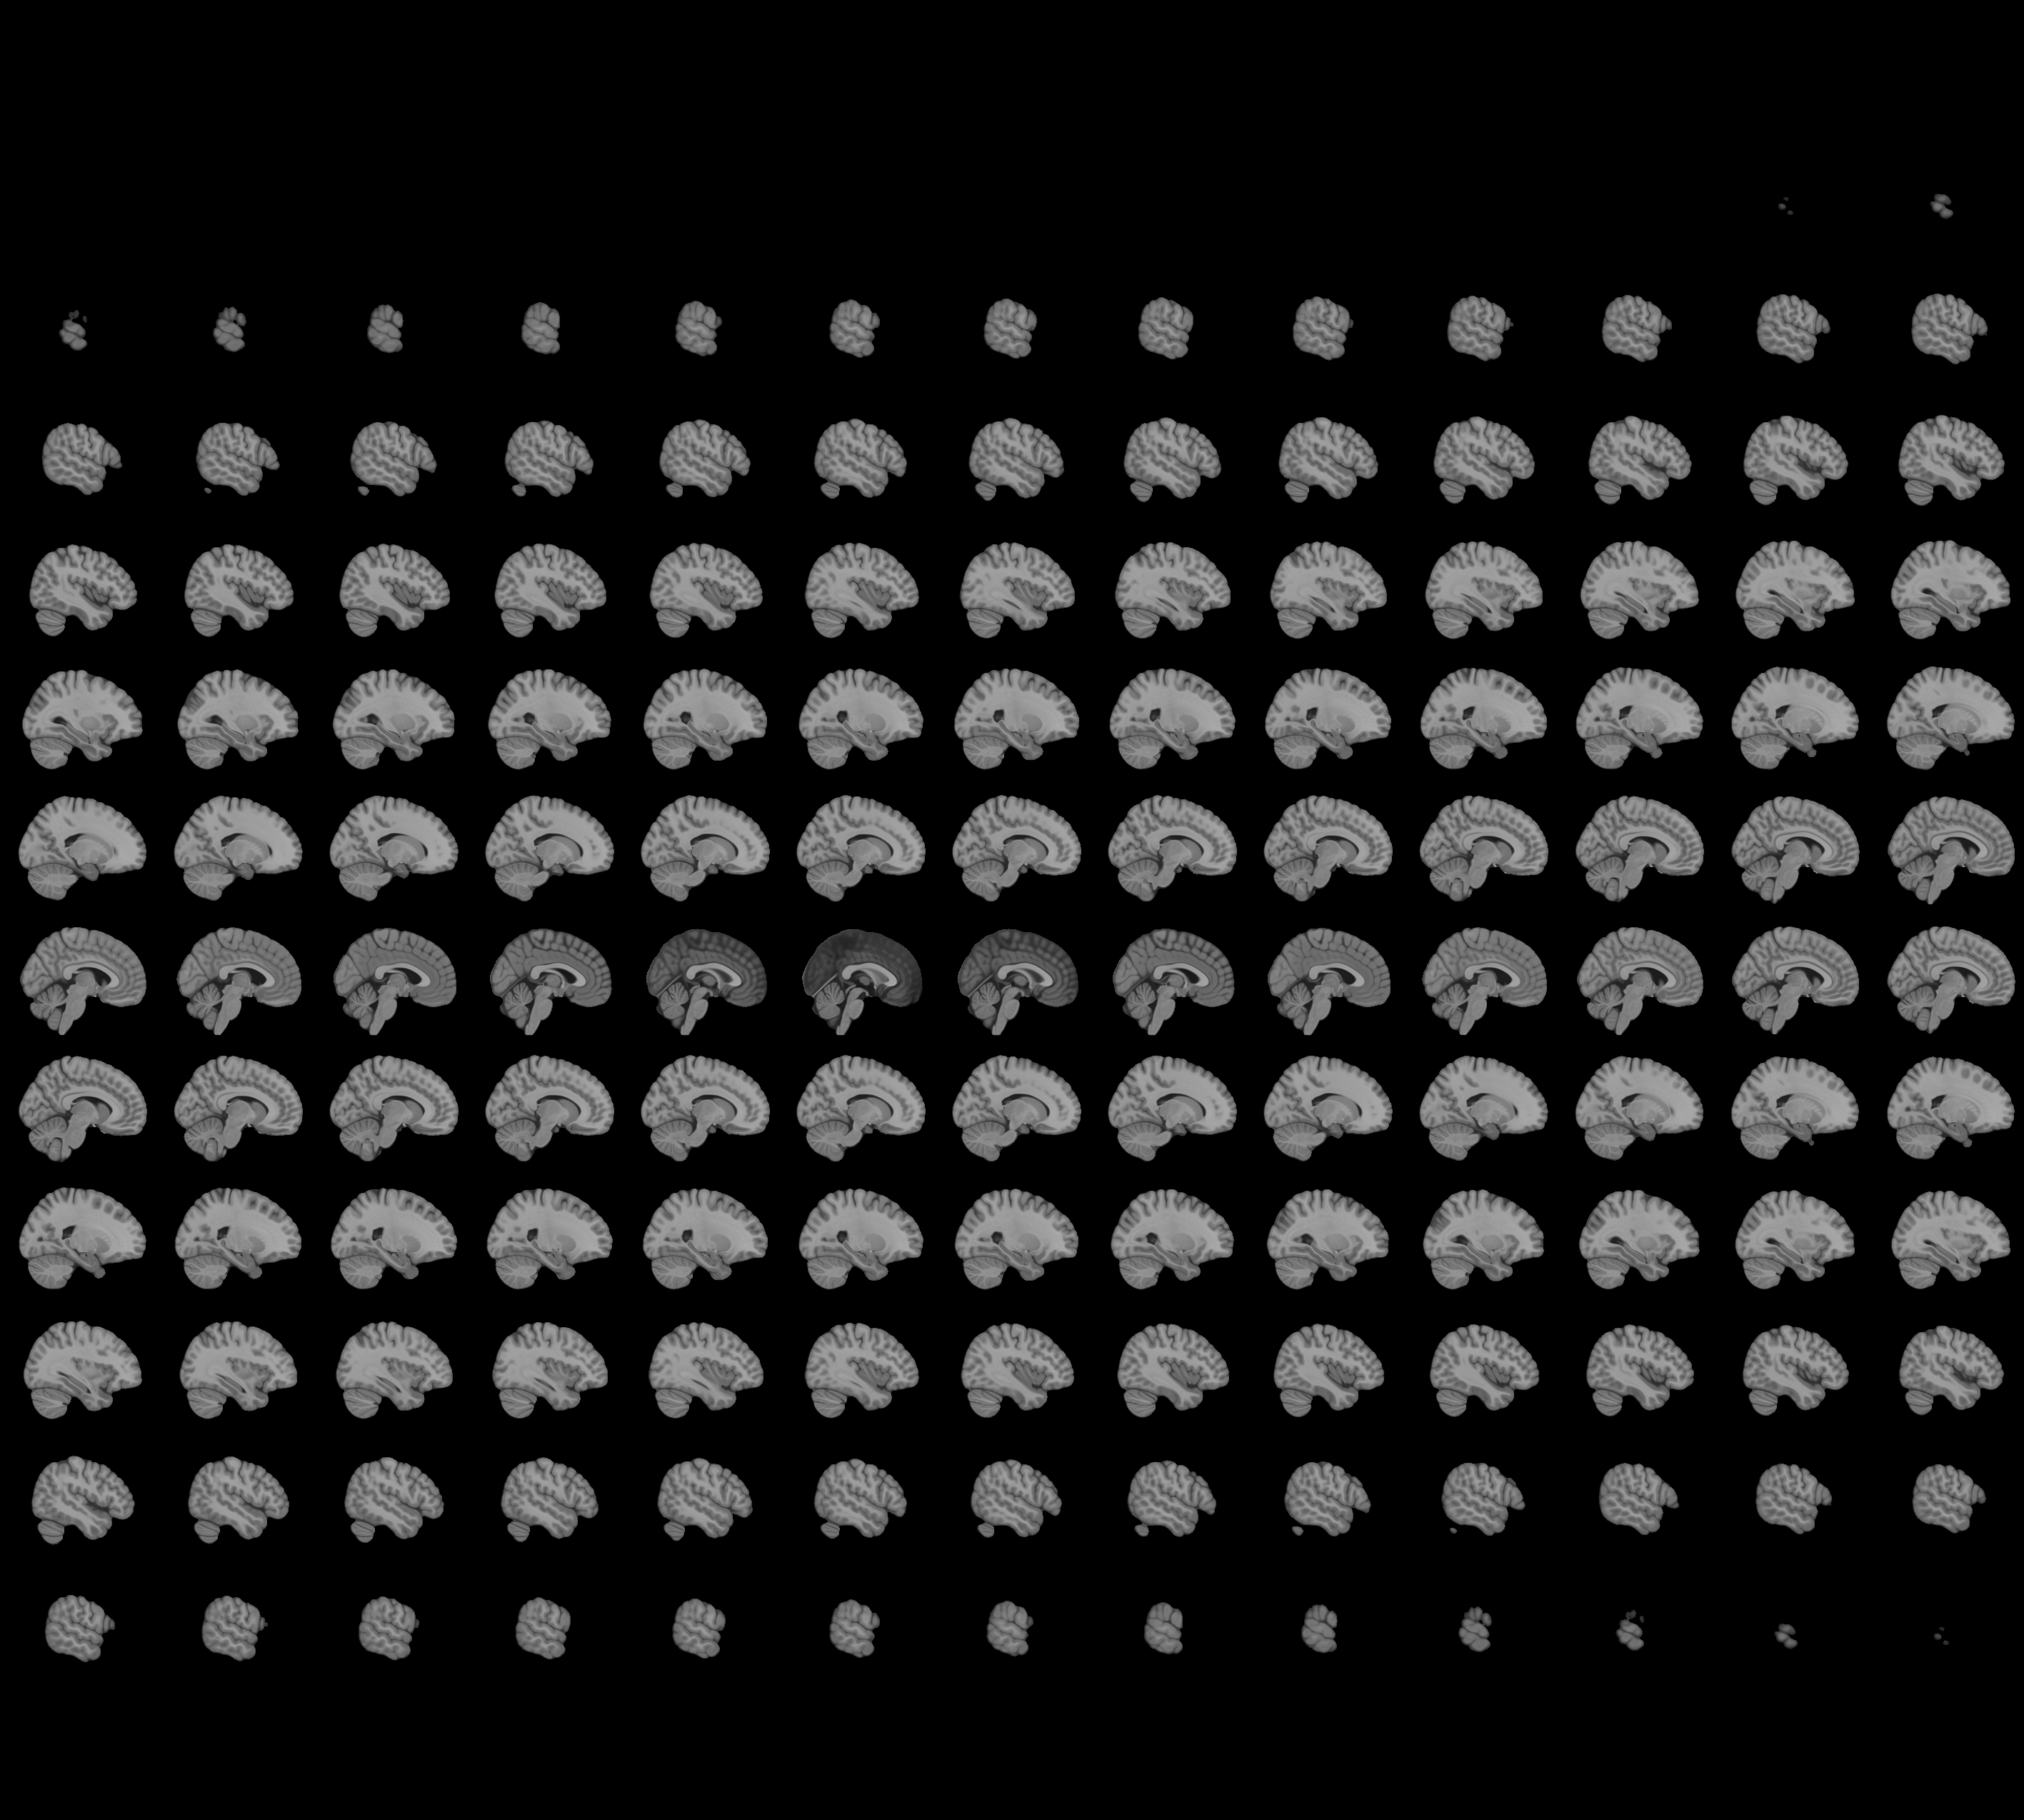
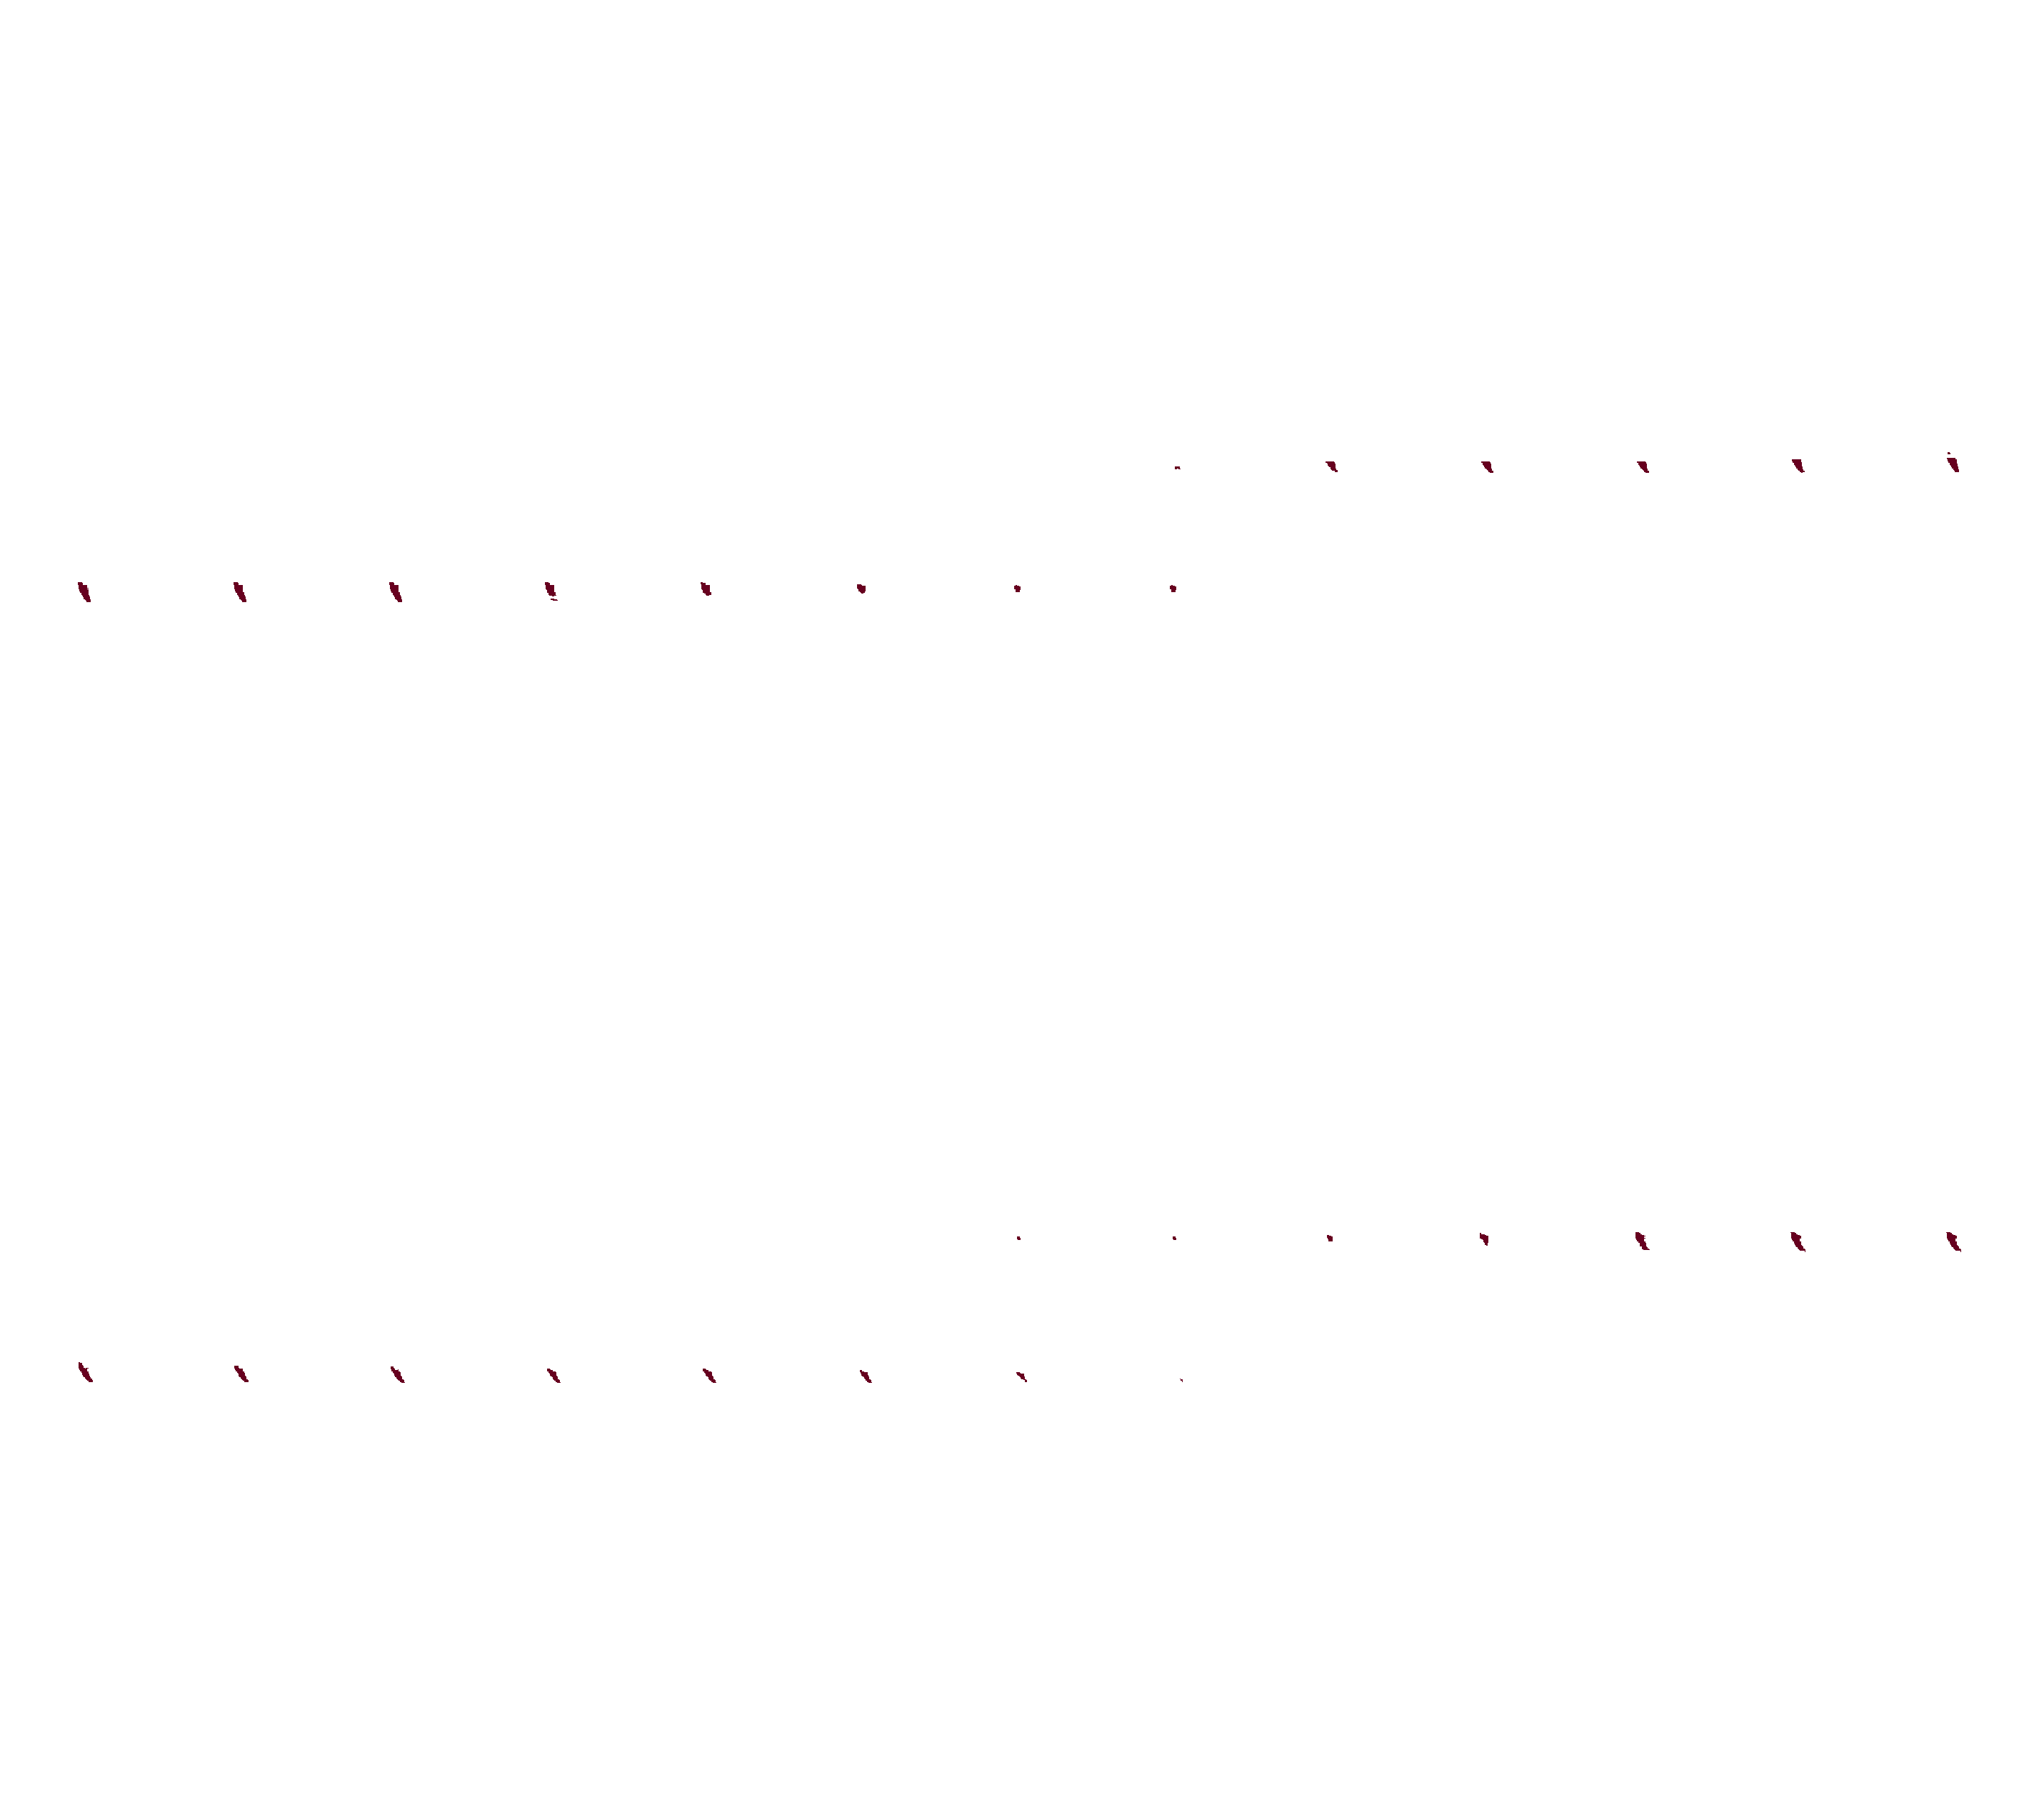

In [119]:
# =========================================
# Checking (visualize)
# =========================================
# Atlas-based (Brainnetome) mask visualization
region = "dIg_L_OR_dIg_R"  # match with target_label
f = (DIR_MASK_OUT if 'DIR_MASK_OUT' in globals() else DIR_MASK_OUT) / f"{region}_BN_prob_mask_MNI.nii.gz"

mask_img = image.load_img(str(f))
mni = datasets.load_mni152_template(resolution=1)
mni = image.resample_to_img(mni, mask_img, interpolation="linear")

# For interactive plot
plotting.view_img(mask_img, bg_img=mni, opacity=0.6, radiological=False)

# # For output
# fig = plotting.plot_roi(roi_img=mask_img, bg_img=mni,alpha=0.6, display_mode='ortho', title=region,draw_cross=False)
# output_path = DIR_MASK_OUT / f"{region}_BN_prob_mask_MNI_overlay.png"
# fig.savefig(output_path, dpi=300, bbox_inches="tight")

In [112]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# ~~~~~~~~~~~~~~~~~~~ REGISTRATION ~~~~~~~~~~~~~~~~~~~
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

In [23]:
# # -------------
# Inverse registration (MNI -> native)
# register MNI T1 template to subject-specific T1 data
# save transformation and apply to LC map
# -in ANTs, fwdtransforms actually maps moving → fixed 
# # -------------

# Define mask file
sourceIM = 'T1w_7T'
filenames = [p.name for p in  DIR_T1FILES]
sub_idx = filenames.index(f"sub-M3101_{sourceIM}.nii")
sub_id = DIR_T1FILES[sub_idx].stem.split("_")[0]

# Oxforx-Harvard (atlases integrated into nypype)
# target_label = "Cingulate Gyrus, anterior division" #Occipital/Frontal Pole, Cingulate Gyrus, anterior division
# target_labelC = target_label.replace(" ", "_").replace(",", "")
# mask_mni = ants.image_read(str(DIR_MASK_OUT / f"{target_labelC}_HO_prob_mask_MNI.nii.gz"))

# Neurosynth/custom made masks
target_label = "dIg_L_OR_dIg_R" 
mask_mni = ants.image_read(str(DIR_MASK_OUT / f"{target_label}_BN_prob_mask_MNI.nii.gz"))
t1_native = ants.image_read(str(DIR_T1FILES[sub_idx]))

# Reorient subject native T1 to RAS (for registration)
# always use original T1 data for neuronavigation
t1_native_ras = ants.reorient_image2(t1_native, orientation='RAS')

# Histogram-match MNI template to native T1
t1_mni_hm = ants.histogram_match_image(
    source_image=t1_mni,
    reference_image=t1_native_ras,
    number_of_histogram_bins=256,
    number_of_match_points=128, 
    use_threshold_at_mean_intensity=True  
    )

# Register MNI T1 → subject native T1
reg_sub_mni = ants.registration(
    fixed=t1_native_ras, 
    moving=t1_mni_hm, 
    type_of_transform='SyN')


# Warp the mask into native space (but in RAS oriented)
mask_native_ras = ants.apply_transforms(
    fixed=t1_native_ras, 
    moving=mask_mni, 
    transformlist=reg_sub_mni['fwdtransforms'],  # use forward transform
    interpolator='nearestNeighbor'  # for binary or probabilistic mask
)

# Confine masks to be within brains 
brain_mask_native = ants.get_mask(t1_native_ras)
mask_native_ras = mask_native_ras * brain_mask_native

# Resample warped mask to match original T1 orientation
mask_native = ants.resample_image_to_target(mask_native_ras, t1_native)

# Output
filename = f"{sub_id}_{sourceIM}_{target_label}_mask_MNI.nii.gz"
filename = filename.replace("_MNI", "_native")
ants.image_write(mask_native, str(DIR_T1FILES[sub_idx].parent / filename))


In [24]:
# ================================
# Split native mask into L / R using BN atlas hemispheres
# ================================
# Requires:
#   - mask_native_ras (ANTsImage, native RAS space)
#   - t1_native, t1_native_ras
#   - reg_sub_mni (MNI -> native registration dict)
#   - filename, DIR_T1FILES, sub_idx
#   - BN atlas + LUT in MNI space

import os
import numpy as np
from pathlib import Path

# --------------------------------
# 1. Load BN atlas and LUT in MNI
# --------------------------------
BN_ROOT = Path(os.getenv("NILEARN_DATA")) / "bn"

bn_atlas_mni = ants.image_read(str(BN_ROOT / "BN_Atlas_246_1mm.nii.gz"))
bn_lut = np.loadtxt(str(BN_ROOT / "BN_Atlas_246_LUT.txt"), dtype=str)

# First column = index, second = label name
bn_ids   = bn_lut[:, 0].astype(int)
bn_names = bn_lut[:, 1].tolist()

left_ids  = [int(idx) for idx, name in zip(bn_ids, bn_names) if name.endswith("_L")]
right_ids = [int(idx) for idx, name in zip(bn_ids, bn_names) if name.endswith("_R")]

print(f"BN atlas left labels:  {len(left_ids)}")
print(f"BN atlas right labels: {len(right_ids)}")

# --------------------------------
# 2. Warp BN atlas to native RAS
# --------------------------------
bn_native_ras = ants.apply_transforms(
    fixed=t1_native_ras,
    moving=bn_atlas_mni,
    transformlist=reg_sub_mni['fwdtransforms'],
    interpolator='nearestNeighbor'
)

bn_np   = bn_native_ras.numpy().astype(int)
mask_np = mask_native_ras.numpy()

# --------------------------------
# 3. Build left/right hemisphere masks from BN labels
# --------------------------------
hemi_L = np.isin(bn_np, left_ids)
hemi_R = np.isin(bn_np, right_ids)

# Intersect your target mask with hemispheres
mask_L_ras = mask_np * hemi_L
mask_R_ras = mask_np * hemi_R

print("Non-zero voxels (RAS):")
print("  Left mask :", mask_L_ras.sum())
print("  Right mask:", mask_R_ras.sum())

# --------------------------------
# 4. Back to ANTs and resample to native T1
# --------------------------------
mask_L_ras_img = ants.from_numpy(
    mask_L_ras,
    origin=mask_native_ras.origin,
    spacing=mask_native_ras.spacing,
    direction=mask_native_ras.direction,
)
mask_R_ras_img = ants.from_numpy(
    mask_R_ras,
    origin=mask_native_ras.origin,
    spacing=mask_native_ras.spacing,
    direction=mask_native_ras.direction,
)

mask_L = ants.resample_image_to_target(mask_L_ras_img, t1_native)
mask_R = ants.resample_image_to_target(mask_R_ras_img, t1_native)

# --------------------------------
# 5. Save with _L / _R suffix
# --------------------------------
base = filename.replace(".nii.gz", "")  # e.g. sub-M3827_T1w_7T_aMCC_..._mask_native

out_L = DIR_T1FILES[sub_idx].parent / f"{base}_L.nii.gz"
out_R = DIR_T1FILES[sub_idx].parent / f"{base}_R.nii.gz"

ants.image_write(mask_L, str(out_L))
ants.image_write(mask_R, str(out_R))

print("Saved L/R native masks (BN-based hemispheres):")
print("  L:", out_L)
print("  R:", out_R)

BN atlas left labels:  123
BN atlas right labels: 123
Non-zero voxels (RAS):
  Left mask : 1305.0
  Right mask: 1393.0
Saved L/R native masks (BN-based hemispheres):
  L: /Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/120921E825_200604M3101.Shibata_CUBE_250623/sub-M3101_T1w_7T_dIg_L_OR_dIg_R_mask_native_L.nii.gz
  R: /Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/120921E825_200604M3101.Shibata_CUBE_250623/sub-M3101_T1w_7T_dIg_L_OR_dIg_R_mask_native_R.nii.gz


✅ Overlay figure saved to: /Users/atsushikikumoto/Dropbox (Personal)/w_SCRIPTS/P.TUSPractice/TUS_LSRDM/PilotData/LCScan_Pilot/7T/120921E825_200604M3101.Shibata_CUBE_250623/sub-M3101_dIg_L_OR_dIg_R_native_overlay.png
[RAS] Brain X-range: 12–241, mid_x=126
Best slice: z_L=122, z_R=119


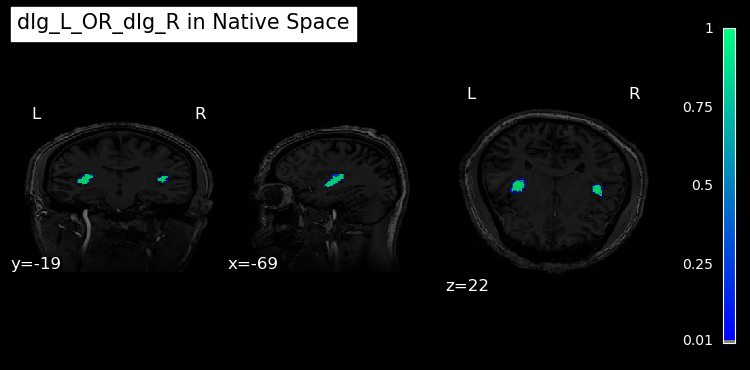

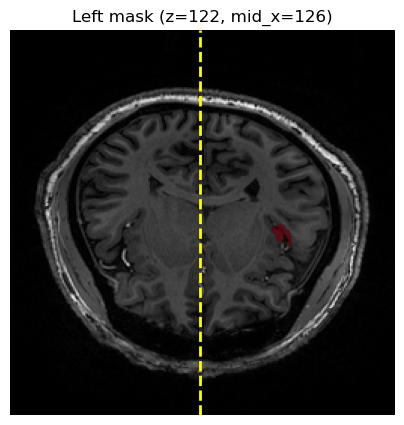

mask_L_ras voxels: 1305.0


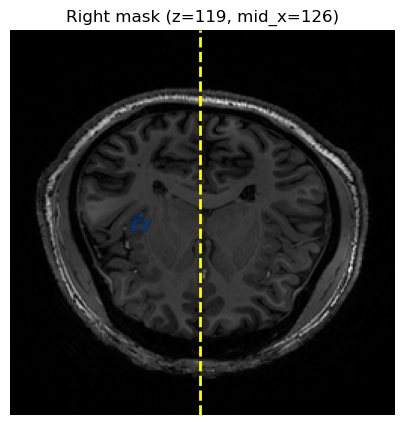

mask_R_ras voxels: 1393.0


In [25]:
# # -------------
# Visualize inverted registration of MNI space 
# # -------------
from IPython.display import HTML

# Convert files
t1_native_nib = ants_to_nib(t1_native)
tmp_warped2native_nib = ants_to_nib(reg_sub_mni['warpedmovout'])
mask_native_nib = ants_to_nib(mask_native)
# # -------------
# Visualize mask transformed from MNI to native space 1
# # -------------

# # Display overlay of native T1 and native mask
# threshold_check = 0
# viewer =  plotting.view_img(ants_to_nib(mask_native>threshold_check),bg_img=ants_to_nib(t1_native),cmap='Reds',threshold=0.01)
# viewer.open_in_browser()  # Opens interactive viewer in default web browser


# # -------------
# Visualize mask transformed from MNI to native space 2
# # -------------

# Threshold and convert to float image for static overlay
mask_native_bin = image.math_img("img > 0", img=mask_native_nib)

# Plot and save
fig = plotting.plot_stat_map(
    stat_map_img=mask_native_nib,
    bg_img=t1_native_nib,
    threshold=0.01,
    display_mode='ortho',
    #cut_coords=(-22, -6, -14),  # left CeA
    #cut_coords=(0, 2, 0),  # approx center of BST
    cmap='winter',
    transparency = .8,
    draw_cross=False,      # <- no cross lines
    title=f"{target_label} in Native Space"
)

# Save figure
output_path = DIR_T1FILES[sub_idx].parent / f"{sub_id}_{target_label}_native_overlay.png"
fig.savefig(output_path, dpi=300)
print(f"✅ Overlay figure saved to: {output_path}")


# ============================
# QA plots for L / R masks
# ============================
import matplotlib.pyplot as plt

# numpy arrays in RAS
t1_ras = t1_native_ras.numpy()
bm_ras = brain_mask_native.numpy()
L_ras = mask_L_ras
R_ras = mask_R_ras

# binary masks for bright display
L_vis = (L_ras > 0).astype(float)
R_vis = (R_ras > 0).astype(float)

# midline from brain mask
xs = np.where(bm_ras.sum(axis=(1, 2)) > 0)[0]
x_min, x_max = xs.min(), xs.max()
mid_x = int(round((x_min + x_max) / 2))
print(f"[RAS] Brain X-range: {x_min}–{x_max}, mid_x={mid_x}")

# slices with maximum area
z_L = np.argmax(L_vis.sum(axis=(0, 1)))
z_R = np.argmax(R_vis.sum(axis=(0, 1)))
print(f"Best slice: z_L={z_L}, z_R={z_R}")

def plot_one(z, show_L=True, show_R=True, title=""):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(t1_ras[:, :, z].T, cmap="gray", origin="lower")

    if show_L:
        ax.imshow(
            np.ma.masked_where(L_vis[:, :, z] == 0, L_vis[:, :, z]).T,
            cmap="Reds", alpha=0.7, origin="lower", vmin=0, vmax=1
        )
    if show_R:
        ax.imshow(
            np.ma.masked_where(R_vis[:, :, z] == 0, R_vis[:, :, z]).T,
            cmap="Blues", alpha=0.7, origin="lower", vmin=0, vmax=1
        )

    ax.axvline(mid_x, color="yellow", linestyle="--", linewidth=2)
    ax.set_title(title)
    ax.axis("off")
    plt.show()

# Left only
plot_one(z_L, show_L=True, show_R=False,
         title=f"Left mask (z={z_L}, mid_x={mid_x})")
print("mask_L_ras voxels:", float(L_ras.sum()))

# Right only
plot_one(z_R, show_L=False, show_R=True,
         title=f"Right mask (z={z_R}, mid_x={mid_x})")
print("mask_R_ras voxels:", float(R_ras.sum()))


In [26]:
# # -------------
# Prepare summarized outputs for TUS (separately )
# # -------------
import ants
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.ndimage import binary_erosion

# --- Threshold and extract coords from initial binary mask ---
# Define target
target_label = "dIg_L_OR_dIg_R"   
sub_id = DIR_T1FILES[sub_idx].stem.split("_")[0]
subject_dir = DIR_T1FILES[sub_idx].parent

# Load and save t1 as RAS orientation for neuronavigation
t1_native = ants.image_read(str(DIR_T1FILES[sub_idx]))
t1_native_ras = ants.reorient_image2(t1_native, orientation='RAS')

# Load pre-warped native-space mask (already thresholded & in native orientation)
mask_native_path = DIR_T1FILES[sub_idx].parent / f"{sub_id}_{sourceIM}_{target_label}_mask_native.nii.gz"
mask_native = ants.image_read(str(mask_native_path))
# mask_native_ras = ants.reorient_image2(mask_native, orientation='RAS')

threshold = 0.0
mask_thresh = mask_native > threshold
mask_np = mask_thresh.numpy()


# Get information about native space T1 data
direction = np.array(t1_native.direction)
spacing = np.array(t1_native.spacing)
origin = np.array(t1_native.origin)

affine = np.eye(4)
affine[:3, :3] = direction * spacing
affine[:3, 3] = origin

i, j, k = np.nonzero(mask_np > 0)
coords_vox = np.c_[i, j, k]
coords_world = coords_vox @ affine[:3, :3].T + origin

# --- Split into hemispheres ---
center_index = np.array(t1_native.shape) / 2  # voxel index
midline_world = origin + direction @ (center_index * spacing)
midline_x = midline_world[0]  # This is anatomically meaningful midline X
left_idx = coords_world[:, 0] < midline_x
right_idx = coords_world[:, 0] > midline_x

# ---Optional:Load segmentation maps ---
# NOTE: these inputs not used to constrain coordinates
c1 = ants.image_read(str(DIR_T1C1FILES[sub_idx]))  # GM
c2 = ants.image_read(str(DIR_T1C2FILES[sub_idx]))  # WM
c3 = ants.image_read(str(DIR_T1C3FILES[sub_idx]))  # CSF
c4 = ants.image_read(str(DIR_T1C4FILES[sub_idx]))  # ???
c5 = ants.image_read(str(DIR_T1C5FILES[sub_idx]))  # Scalp
c6 = ants.image_read(str(DIR_T1C6FILES[sub_idx]))  # Background

# --- Optional:Dilate scalp to include near-surface tissues ---
c5_dilated = ants.morphology(c5, operation='dilate', radius=2)

# --- Optional:Subtract binarized background ---
c6_bin = (c6.numpy() > 0.1).astype(np.uint8)  # More conservative subtraction

# --- Optional:Combine tissues and subtract background ---
combined_np = (
    c1.numpy() + c2.numpy() + c3.numpy() + c4.numpy() + c5_dilated.numpy()
)
combined_cleaned = combined_np * (1 - c6_bin)

# --- Optional: Smooth and binarize ---
smoothed_prob = gaussian_filter(combined_cleaned, sigma=1)
combined_mask = (smoothed_prob > 0.2).astype(np.uint8)

# --- Optional: restrict to surface shell ---
eroded = binary_erosion(combined_mask, iterations=2)
surface_mask = combined_mask.copy()
surface_mask[eroded > 0] = 0


# --- Optional:Convert to world coordinates ---
surface_i, surface_j, surface_k = np.nonzero(surface_mask)
surface_vox = np.c_[surface_i, surface_j, surface_k]
surface_world = surface_vox @ affine[:3, :3].T + origin

# --- Ready for outputs ---
rows = []

for hemi_label, hemi_idx in zip(["R", "L"], [left_idx, right_idx]):
    if hemi_idx.sum() == 0:
        continue

    # Hemisphere mask
    hemi_mask = np.zeros_like(mask_np)
    hemi_mask[i[hemi_idx], j[hemi_idx], k[hemi_idx]] = 1
    hemi_mask_ants = ants.from_numpy(
        hemi_mask,
        origin=tuple(origin),
        spacing=tuple(spacing),
        direction=tuple(direction)
    )

    # Center of mass
    label_image = hemi_mask_ants * 1
    stats = ants.label_stats(hemi_mask_ants, label_image)
    stats_label_1 = stats[stats['LabelValue'] == 1.0]
    com_xyz = np.array([
        stats_label_1['x'].values[0],
        stats_label_1['y'].values[0],
        stats_label_1['z'].values[0]
    ])

    # --- Optional: restrict surface points to superior skull only ---
    keep_idx = surface_world[:, 2] > (com_xyz[2] - 10)
    filtered_surface = surface_world[keep_idx]

    # --- Compute minimum distance ---
    dists = cdist([com_xyz], filtered_surface)
    min_dist = float(np.min(dists))
    closest_point = filtered_surface[np.argmin(dists)]

    # Orientation matrix
    m = affine[:3, :3]

    # Save
    rows.append({
        'subject_id': sub_id,
        'hemisphere': hemi_label,
        'mask_used': mask_native_path.name,
        'x': com_xyz[0],
        'y': com_xyz[1],
        'z': com_xyz[2],
        #'distance_to_scalp': round(min_dist, 2),
        #'x_closest_scalp': closest_point[0],
        #'y_closest_scalp': closest_point[1],
        #'z_closest_scalp': closest_point[2],
        'count': stats_label_1['Count'].values[0],
        'volume': stats_label_1['Volume'].values[0],
        'mass': stats_label_1['Mass'].values[0],
        't1_path': str(DIR_T1FILES[sub_idx]),
        "m0n0": m[0, 0], "m0n1": m[0, 1], "m0n2": m[0, 2],
        "m1n0": m[1, 0], "m1n1": m[1, 1], "m1n2": m[1, 2],
        "m2n0": m[2, 0], "m2n1": m[2, 1], "m2n2": m[2, 2]
    })

# --- Save full detailed CSV ---
df_out = pd.DataFrame(rows)
csv_filename = f"{sub_id}_{sourceIM}_{target_label}_target_coordinates_native.csv"
csv_path = subject_dir / csv_filename

# --- Save Brainsight-compatible TXT (tab-delimited, flipped X/Y coords + orientation) ---
brainsight_header = [
    "# Version: 13",
    "# Coordinate system: NIfTI:Scanner",
    "# Created by: Brainsight 2.5.1",
    "# Units: millimetres, degrees, milliseconds, and microvolts",
    "# Encoding: UTF-8",
    "# Notes: Each column is delimited by a tab. Each value within a column is delimited by a semicolon.",
    "# Target Name\tLoc. X\tLoc. Y\tLoc. Z\tm0n0\tm0n1\tm0n2\tm1n0\tm1n1\tm1n2\tm2n0\tm2n1\tm2n2"
]

rows_bs = []

for _, row in df_out.iterrows():
    hemi = row['hemisphere']
    label = f"{target_label}_{hemi}"

    # Orientation matrix in native space
    m_native = np.array([
        [row["m0n0"], row["m0n1"], row["m0n2"]],
        [row["m1n0"], row["m1n1"], row["m1n2"]],
        [row["m2n0"], row["m2n1"], row["m2n2"]],
    ])
    m_flipped = np.diag([-1, -1, 1]) @ m_native  # RAS to LAS

    # --- Add Target Point ---
    rows_bs.append({
        "Target Name": f"{label}_Target",
        "Loc. X": round(-row["x"], 4),
        "Loc. Y": round(-row["y"], 4),
        "Loc. Z": round(row["z"], 4),
        "m0n0": round(m_flipped[0, 0], 6), "m0n1": round(m_flipped[0, 1], 6), "m0n2": round(m_flipped[0, 2], 6),
        "m1n0": round(m_flipped[1, 0], 6), "m1n1": round(m_flipped[1, 1], 6), "m1n2": round(m_flipped[1, 2], 6),
        "m2n0": round(m_flipped[2, 0], 6), "m2n1": round(m_flipped[2, 1], 6), "m2n2": round(m_flipped[2, 2], 6),
    })

    # --- Add Closest Scalp Point ---
    #rows_bs.append({
    #    "Target Name": f"{label}_Scalp",
    #    "Loc. X": round(-row["x_closest_scalp"], 4),
    #    "Loc. Y": round(-row["y_closest_scalp"], 4),
    #    "Loc. Z": round(row["z_closest_scalp"], 4),
    #    "m0n0": round(m_flipped[0, 0], 6), "m0n1": round(m_flipped[0, 1], 6), "m0n2": round(m_flipped[0, 2], 6),
    #    "m1n0": round(m_flipped[1, 0], 6), "m1n1": round(m_flipped[1, 1], 6), "m1n2": round(m_flipped[1, 2], 6),
    #    "m2n0": round(m_flipped[2, 0], 6), "m2n1": round(m_flipped[2, 1], 6), "m2n2": round(m_flipped[2, 2], 6),
    #})

# Save TXT
df_brainsight = pd.DataFrame(rows_bs)
bs_filename = f"{sub_id}_{sourceIM}_{target_label}_target_coordinates_BrainsightTargets.txt"
bs_path = subject_dir / bs_filename
with open(bs_path, "w", encoding="utf-8") as f:
    for line in brainsight_header:
        f.write(line + "\n")
    df_brainsight.to_csv(f, sep="\t", index=False, header=False)

# --- Preview
df_out


,subject_id,hemisphere,mask_used,x,y,z,count,volume,mass,t1_path,m0n0,m0n1,m0n2,m1n0,m1n1,m1n2,m2n0,m2n1,m2n2
0,sub-M3101,R,sub-M3101_T1w_7T_dIg_L_OR_dIg_R_mask_native.ni...,-35.889225,-19.936909,-1.318354,2146.0,1716.800049,2146.0,/Users/atsushikikumoto/Dropbox (Personal)/w_SC...,-0.00558,0.0,-0.799988,0.999984,-0.00026,-0.004464,-0.00026,-1.0,0.000001
1,sub-M3101,L,sub-M3101_T1w_7T_dIg_L_OR_dIg_R_mask_native.ni...,38.419522,-26.291012,-4.253236,1534.0,1227.200073,1534.0,/Users/atsushikikumoto/Dropbox (Personal)/w_SC...,-0.00558,0.0,-0.799988,0.999984,-0.00026,-0.004464,-0.00026,-1.0,0.000001
